# **LAB ASSIGNMENT - 7**

**Install & Import Libraries**

In [4]:
!pip install tensorflow scikit-learn matplotlib seaborn -q

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time

**Load CIFAR-10 Dataset**

In [6]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


**Data Preprocessing**

In [7]:
# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Sample label after encoding:", y_train[0])

Sample label after encoding: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


**Visualize Dataset**

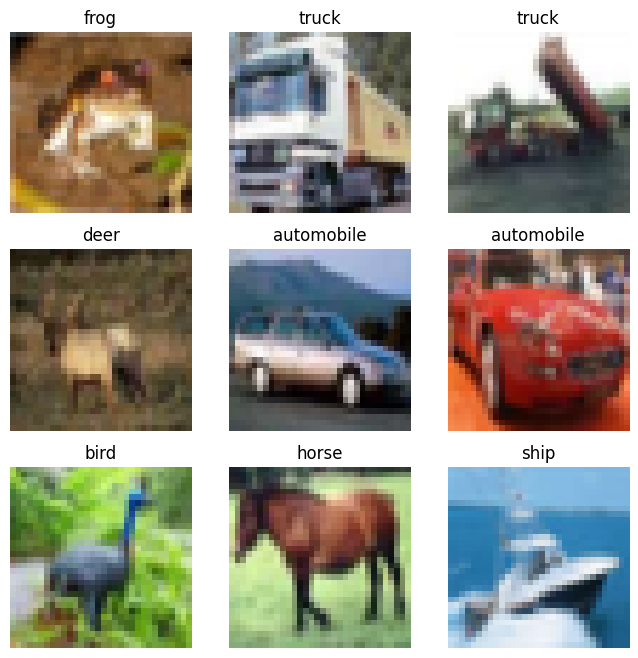

In [8]:
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[np.argmax(y_train[i])])
    plt.axis("off")

plt.show()

**Build CNN Model**

In [10]:
model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(5,5),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(7,7),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,258 (2.74 MB)

 Trainable params: 717,258 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [11]:
start = time.time()

history = model.fit(
    x_train,y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

training_time = time.time() - start

print("Training time:",training_time,"seconds")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3752 - loss: 1.7091 - val_accuracy: 0.5136 - val_loss: 1.3541
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5373 - loss: 1.3035 - val_accuracy: 0.5993 - val_loss: 1.1397
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6125 - loss: 1.1102 - val_accuracy: 0.6516 - val_loss: 0.9862
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6691 - loss: 0.9552 - val_accuracy: 0.6977 - val_loss: 0.8713
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7148 - loss: 0.8311 - val_accuracy: 0.6942 - val_loss: 0.8890
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7494 - loss: 0.7273 - val_accuracy: 0.6959 - val_loss: 0.8882
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7802 - loss: 0.6349 - val_accuracy: 0.7111 - val_loss: 0.8719
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8079 - loss: 0.5518 - val_accuracy: 

**Plot Training History**

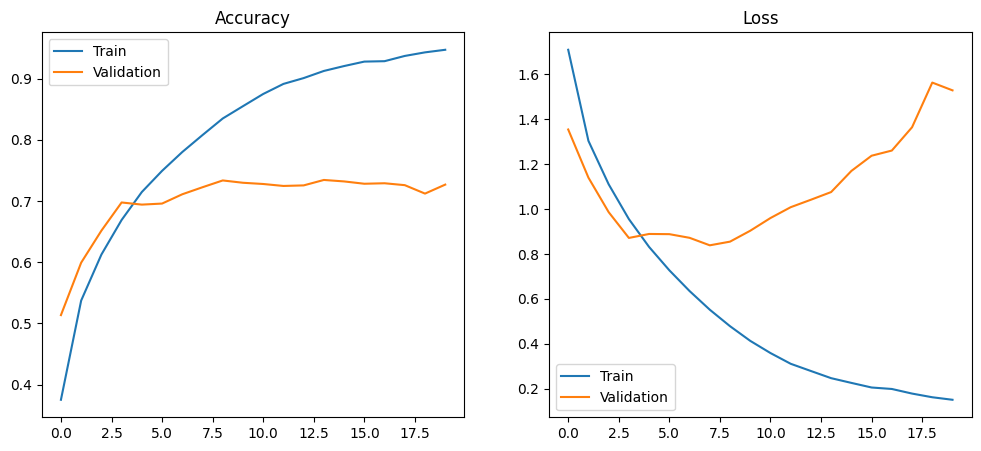

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

**Evaluate on Clean Dataset**

In [13]:
loss,acc = model.evaluate(x_test,y_test)

print("Clean Test Accuracy:",acc)
print("Clean Test Loss:",loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7214 - loss: 1.5976
Clean Test Accuracy: 0.7214000225067139
Clean Test Loss: 1.5976048707962036


**FGSM Attack**

In [14]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(image,label,epsilon):

    image = tf.convert_to_tensor(image)
    label = tf.convert_to_tensor(label)

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = loss_object(label,prediction)

    gradient = tape.gradient(loss,image)
    signed_grad = tf.sign(gradient)

    adv_image = image + epsilon*signed_grad
    adv_image = tf.clip_by_value(adv_image,0,1)

    return adv_image

**Generate FGSM Images**

In [15]:
epsilon = 0.03

x_test_tensor = tf.convert_to_tensor(x_test)

adv_images = fgsm_attack(x_test_tensor,y_test,epsilon)

print("Adversarial images generated")

Adversarial images generated


**Evaluate FGSM Attack**

In [16]:
loss_fgsm,acc_fgsm = model.evaluate(adv_images,y_test)

print("FGSM Accuracy:",acc_fgsm)
print("FGSM Loss:",loss_fgsm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1011 - loss: 17.1659
FGSM Accuracy: 0.10109999775886536
FGSM Loss: 17.16591453552246


**BIM Attack**

In [17]:
def bim_attack(images,labels,epsilon=0.03,alpha=0.005,iters=10):

    adv = images

    for i in range(iters):

        with tf.GradientTape() as tape:
            tape.watch(adv)
            prediction = model(adv)
            loss = loss_object(labels,prediction)

        grad = tape.gradient(loss,adv)

        adv = adv + alpha*tf.sign(grad)

        adv = tf.clip_by_value(adv,images-epsilon,images+epsilon)
        adv = tf.clip_by_value(adv,0,1)

    return adv

**Evaluate BIM**

In [18]:
adv_bim = bim_attack(x_test_tensor,y_test)

loss_bim,acc_bim = model.evaluate(adv_bim,y_test)

print("BIM Accuracy:",acc_bim)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0146 - loss: 36.6568
BIM Accuracy: 0.014600000344216824


**PGD Attack**

In [19]:
def pgd_attack(images,labels,epsilon=0.03,alpha=0.005,iters=20):

    adv = images + tf.random.normal(images.shape,-epsilon,epsilon)

    for i in range(iters):

        with tf.GradientTape() as tape:
            tape.watch(adv)
            prediction = model(adv)
            loss = loss_object(labels,prediction)

        grad = tape.gradient(loss,adv)

        adv = adv + alpha*tf.sign(grad)

        adv = tf.clip_by_value(adv,images-epsilon,images+epsilon)
        adv = tf.clip_by_value(adv,0,1)

    return adv

**Evaluate PGD**

In [20]:
adv_pgd = pgd_attack(x_test_tensor,y_test)

loss_pgd,acc_pgd = model.evaluate(adv_pgd,y_test)

print("PGD Accuracy:",acc_pgd)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0094 - loss: 39.6402
PGD Accuracy: 0.009399999864399433


**Confusion Matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


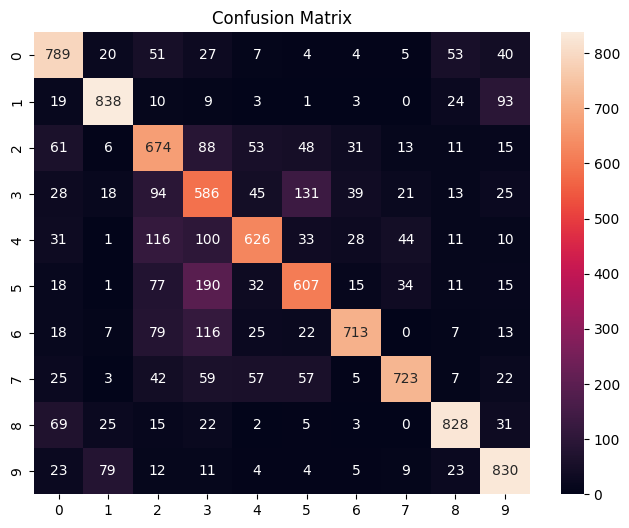

In [21]:
pred = model.predict(x_test)
y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(y_test,axis=1)

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

**Precision Recall F1**

In [22]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1000
           1       0.84      0.84      0.84      1000
           2       0.58      0.67      0.62      1000
           3       0.49      0.59      0.53      1000
           4       0.73      0.63      0.68      1000
           5       0.67      0.61      0.63      1000
           6       0.84      0.71      0.77      1000
           7       0.85      0.72      0.78      1000
           8       0.84      0.83      0.83      1000
           9       0.76      0.83      0.79      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



**Visualize Adversarial Examples**

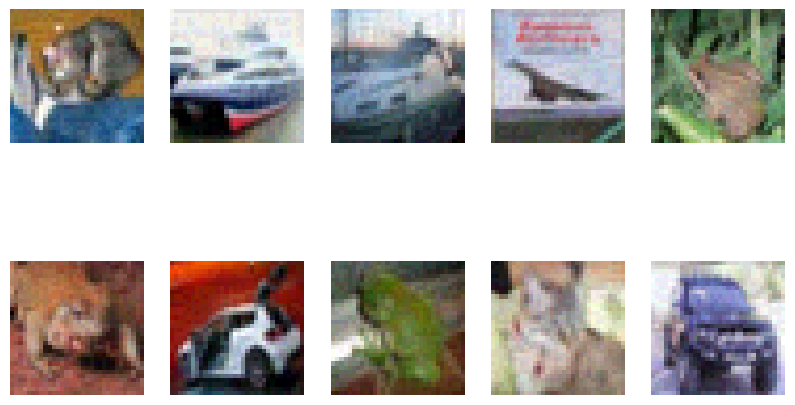

In [23]:
plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(adv_images[i])
    plt.axis("off")

plt.show()

**Comparison Table**

In [24]:
print("Attack Comparison")

print("Clean Accuracy:",acc)
print("FGSM Accuracy:",acc_fgsm)
print("BIM Accuracy:",acc_bim)
print("PGD Accuracy:",acc_pgd)

Attack Comparison
Clean Accuracy: 0.7214000225067139
FGSM Accuracy: 0.10109999775886536
BIM Accuracy: 0.014600000344216824
PGD Accuracy: 0.009399999864399433


In [26]:
model.save("cnn_cifar10_model.h5")

print("Model saved successfully")

Model saved successfully


**Summary:** This assignment explores the impact of adversarial attacks on deep learning models. A Convolutional Neural Network (CNN) was trained on the CIFAR-10 dataset after preprocessing the images through normalization and one-hot encoding of labels. The model used three convolutional layers with different kernel sizes followed by pooling and dense layers for classification.

After training, the model was evaluated on clean test data and then tested against three adversarial attack methods: FGSM, BIM, and PGD. These attacks generate small perturbations in input images using gradient information, which can mislead the model without noticeably changing the image to humans.

The results showed that adversarial attacks significantly reduce the model’s accuracy, with iterative attacks like BIM and PGD generally being stronger than FGSM. This experiment highlights the vulnerability of neural networks to adversarial inputs and emphasizes the need for more robust machine learning models.